In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_amb.mat to dataset_amb.mat
Saving dataset_elec.mat to dataset_elec.mat


In [4]:
df.head()

,vdc1,vdc2,idc1,idc2,irr,pvt,f_nv,p_meas,p_theo,delta_str,severity_index
31800,348.113,349.770,0.2255,0.0511,305.430,5.3711,4,96.372728,1.762009e+06,0.629081,1.0
31801,345.992,351.611,0.2342,0.0519,305.382,5.3786,4,99.279937,1.761683e+06,0.632381,1.0
31803,347.424,346.329,0.2313,0.0562,305.205,5.3815,4,99.822861,1.760643e+06,0.610035,1.0
31805,344.033,349.751,0.2325,0.0556,306.015,5.3916,4,99.433828,1.765249e+06,0.608862,1.0
31808,350.183,351.696,0.2254,0.0537,306.480,5.4152,4,97.817323,1.767777e+06,0.613850,1.0


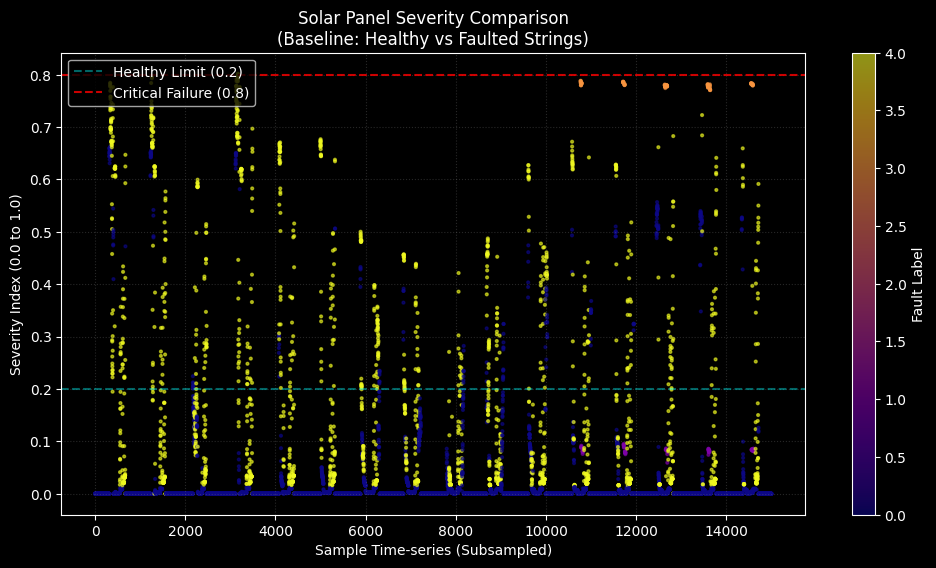

In [5]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
amb = scipy.io.loadmat('dataset_amb.mat')
elec = scipy.io.loadmat('dataset_elec.mat')

# 2. CONSTRUCT DATAFRAME
df = pd.DataFrame({
    'vdc1': elec['vdc1'].flatten(),
    'vdc2': elec['vdc2'].flatten(),
    'idc1': elec['idc1'].flatten(),
    'idc2': elec['idc2'].flatten(),
    'irr': amb['irr'].flatten(),
    'pvt': amb['pvt'].flatten(),
    'f_nv': amb['f_nv'].flatten()
})

# Keep Healthy (0), Soiling (1), String Fault (3), Hardware (4).
# We drop 2 (Shading) as per previous context.
df = df[df['f_nv'].isin([0, 1, 3, 4])].copy()

# 3. BASELINE CALIBRATION (Using Healthy Data)
# We find the median performance of healthy strings to set the P_RATED
healthy_mask = (df['f_nv'] == 0) & (df['irr'] > 800)
if healthy_mask.any():
    p_meas_healthy = (df.loc[healthy_mask, 'vdc1'] * df.loc[healthy_mask, 'idc1']) + \
                     (df.loc[healthy_mask, 'vdc2'] * df.loc[healthy_mask, 'idc2'])
    p_rated_est = (p_meas_healthy / (df.loc[healthy_mask, 'irr'] / 1000)).median()
else:
    p_rated_est = ((df['vdc1'] * df['idc1']) + (df['vdc2'] * df['idc2'])).max()

# 4. FEATURE ENGINEERING
GAMMA = -0.004  # Temp coefficient
REF_TEMP = 25
df['p_meas'] = (df['vdc1'] * df['idc1']) + (df['vdc2'] * df['idc2'])
df['p_theo'] = p_rated_est * (df['irr'] / 1000) * (1 + GAMMA * (df['pvt'] - REF_TEMP))

# String Mismatch Component
df['delta_str'] = np.abs((df['vdc1']*df['idc1']) - (df['vdc2']*df['idc2'])) / (df['p_meas'] + 1e-6)

# 5. SEVERITY INDEX CALCULATION (Vectorized)
# Component 1: Power Loss relative to Healthy Baseline
p_loss = np.where(df['p_theo'] > 5, np.clip(1 - (df['p_meas'] / df['p_theo']), 0, 1), 0)

# Component 2: Thermal Stress
thermal_stress = np.where(df['pvt'] > 60, np.clip((df['pvt'] - 60) / 40, 0, 1), 0)

# Component 3: Fault Type Weight (Omega)
# f_nv=0 stays at weight 1.0 (no extra penalty)
fault_weights = {0: 1.0, 1: 1.5, 3: 1.5, 4: 1.2}
omega = df['f_nv'].map(fault_weights).fillna(1.0)

# Weighted combination (Weights: Power Loss 50%, Mismatch 30%, Thermal 20%)
w1, w2, w3 = 0.5, 0.3, 0.2
severity = (w1 * p_loss + w2 * df['delta_str'] + w3 * thermal_stress) * omega

# Final normalization and cleaning
df['severity_index'] = np.clip(severity, 0, 1)
df.loc[df['irr'] < 50, 'severity_index'] = 0 # Zero out during night/low light

# 6. DARK THEME PLOT
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

# Subsample for clear visualization
sample = df.sample(n=min(15000, len(df)), random_state=42).sort_index()
scatter = plt.scatter(range(len(sample)), sample['severity_index'],
            c=sample['f_nv'], cmap='plasma', s=4, alpha=0.6)

plt.axhline(y=0.2, color='cyan', linestyle='--', alpha=0.4, label='Healthy Limit (0.2)')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.8, label='Critical Failure (0.8)')

plt.colorbar(scatter, label='Fault Label')
plt.title('Solar Panel Severity Comparison\n(Baseline: Healthy vs Faulted Strings)')
plt.ylabel('Severity Index (0.0 to 1.0)')
plt.xlabel('Sample Time-series (Subsampled)')
plt.legend(loc='upper left')
plt.grid(color='gray', linestyle=':', alpha=0.3)
plt.show()

# 7. EXPORT
df.to_csv('solar_severity_with_baseline.csv', index=False)

In [17]:
print(df[df['f_nv']==0].describe())

               vdc1          vdc2          idc1          idc2           irr  \
count  1.162931e+06  1.162931e+06  1.162931e+06  1.162931e+06  1.162931e+06   
mean   1.092099e+02  1.089400e+02  1.866807e+00  1.768347e+00  2.048314e+02   
std    1.316979e+02  1.315317e+02  3.145143e+00  3.076162e+00  3.470097e+02   
min    3.799000e-01  3.164000e-01  4.180000e-02  4.600000e-03 -3.810000e-02   
25%    7.980000e-01  7.724000e-01  6.630000e-02  1.020000e-02  1.263300e+00   
50%    1.906900e+00  2.180600e+00  1.099000e-01  4.030000e-02  1.441900e+00   
75%    2.668840e+02  2.671050e+02  1.104000e+00  1.031550e+00  2.602400e+02   
max    3.639740e+02  3.687490e+02  9.654900e+00  9.433900e+00  1.085920e+03   

                pvt       f_nv        p_meas        p_theo     delta_str  \
count  1.162931e+06  1162931.0  1.162931e+06  1.162931e+06  1.162931e+06   
mean   2.081519e+01        0.0  9.622015e+02  9.286719e+02  4.112873e-01   
std    1.383588e+01        0.0  1.679670e+03  1.561275e+03  

In [18]:
from google.colab import files
files.download('solar_severity_with_baseline.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>